In [43]:
"""
[example_load.py]
팀원용 데이터 로드 예시
------------------------------------------------
이 코드를 그대로 복사해서 본인 노트북 맨 위 셀에 붙여넣으면
X_train, y_train, X_val, y_val이 바로 준비됩니다.

사전 준비 (최초 1회, 프로젝트 루트에서 실행):
    python src/data.py
    python src/prepare_data.py

주의: Test 데이터(X_test, y_test)는 data/preprocessed/에 파일로 존재하지만,
최종 모델 평가 전용이라 이 example에서는 의도적으로 불러오지 않습니다.
Val로 모델을 충분히 비교한 뒤, 최종 후보가 정해지면 Test로 평가할거에요
"""

import pandas as pd
import pickle

DATA_DIR = "../../data/preprocessed"  # 노트북이 notebooks/ 안에 있다면 "../data/preprocessed"로 수정

# Train / Val만 로드 (Test 제외)
X_train = pd.read_csv(f"{DATA_DIR}/X_train.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv")["churn"]

X_val = pd.read_csv(f"{DATA_DIR}/X_val.csv")
y_val = pd.read_csv(f"{DATA_DIR}/y_val.csv")["churn"]

# 전처리 Pipeline (필요 시 새 데이터에 동일 변환 적용할 때 사용)
with open(f"{DATA_DIR}/preprocessor.pkl", "rb") as f:
    preprocessor = pickle.load(f)

print("X_train:", X_train.shape, "| X_val:", X_val.shape)
print("이탈률 - train:", y_train.mean().round(3), "| val:", y_val.mean().round(3))

# 이제 X_train, y_train으로 모델 학습하고 X_val, y_val로 성능을 비교하면 됩니다.
# 예)
#   model.fit(X_train, y_train)
#   from sklearn.metrics import recall_score
#   pred = model.predict(X_val)
#   print(recall_score(y_val, pred))

X_train: (2592, 10) | X_val: (864, 10)
이탈률 - train: 0.494 | val: 0.494


## BASELINE 설정용 로지스틱 회귀분석

In [44]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, precision_score, roc_auc_score, classification_report

X_train = pd.read_csv("../../data/preprocessed/X_train.csv")
y_train = pd.read_csv("../../data/preprocessed/y_train.csv")["churn"]
X_val = pd.read_csv("../../data/preprocessed/X_val.csv")
y_val = pd.read_csv("../../data/preprocessed/y_val.csv")["churn"]

# 다중공선성 처리: avg_days_between_orders 제외 (recency_days와 상관 0.72)
drop_cols = ["avg_days_between_orders"]
X_train_lr = X_train.drop(columns=drop_cols)
X_val_lr = X_val.drop(columns=drop_cols)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_lr, y_train)

pred = model.predict(X_val_lr)
proba = model.predict_proba(X_val_lr)[:, 1]

print("Recall:", round(recall_score(y_val, pred), 3))
print("Precision:", round(precision_score(y_val, pred), 3))
print("AUC:", round(roc_auc_score(y_val, proba), 3))
print(classification_report(y_val, pred))

Recall: 0.677
Precision: 0.69
AUC: 0.757
              precision    recall  f1-score   support

           0       0.69      0.70      0.70       437
           1       0.69      0.68      0.68       427

    accuracy                           0.69       864
   macro avg       0.69      0.69      0.69       864
weighted avg       0.69      0.69      0.69       864



In [45]:
coef_df = pd.DataFrame({
    "feature": X_train_lr.columns,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

print(coef_df)

                 feature  coefficient
0            net_revenue    -0.557430
8  recent_activity_ratio    -0.482266
2              frequency    -0.458773
1           recency_days     0.360938
3      distinct_products    -0.316117
6                  is_uk    -0.155653
4            tenure_days     0.146562
7             has_return    -0.074126
5           is_low_value    -0.037721


In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {"C": [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid,
    scoring="recall",
    cv=5
)
grid.fit(X_train_lr, y_train)

print("최적 C:", grid.best_params_)
print("최적 Recall(CV):", round(grid.best_score_, 3))

# 최적 모델로 Val 재평가
best_model = grid.best_estimator_
pred = best_model.predict(X_val_lr)
proba = best_model.predict_proba(X_val_lr)[:, 1]

from sklearn.metrics import recall_score, precision_score, roc_auc_score

print("Val Recall:", round(recall_score(y_val, pred), 3))
print("Val Precision:", round(precision_score(y_val, pred), 3))
print("Val AUC:", round(roc_auc_score(y_val, proba), 3))

최적 C: {'C': 1}
최적 Recall(CV): 0.709
Val Recall: 0.677
Val Precision: 0.69
Val AUC: 0.757


## 랜덤포레스트

In [47]:
# 랜덤포레스트용 — 원본 10개 피처 그대로 사용 (트리 계열, 다중공선성 무관)
X_train = pd.read_csv("../../data/preprocessed/X_train.csv")
y_train = pd.read_csv("../../data/preprocessed/y_train.csv")["churn"]
X_val = pd.read_csv("../../data/preprocessed/X_val.csv")
y_val = pd.read_csv("../../data/preprocessed/y_val.csv")["churn"]

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, roc_auc_score, classification_report

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_val)
proba = model.predict_proba(X_val)[:, 1]

print("Recall:", round(recall_score(y_val, pred), 3))
print("Precision:", round(precision_score(y_val, pred), 3))
print("AUC:", round(roc_auc_score(y_val, proba), 3))

Recall: 0.677
Precision: 0.663
AUC: 0.737


In [48]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_leaf": [1, 5, 10],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("최적 파라미터:", grid.best_params_)
print("최적 Recall(CV):", round(grid.best_score_, 3))

best_rf = grid.best_estimator_
pred = best_rf.predict(X_val)
proba = best_rf.predict_proba(X_val)[:, 1]   # ← final_rf → best_rf로 수정
print("Val Recall:", round(recall_score(y_val, pred), 3))
print("Val Precision:", round(precision_score(y_val, pred), 3))
print("Val AUC:", round(roc_auc_score(y_val, proba), 3))

최적 파라미터: {'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 300}
최적 Recall(CV): 0.773
Val Recall: 0.738
Val Precision: 0.683
Val AUC: 0.769


In [49]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 7],
    "min_samples_leaf": [5, 10, 15, 20],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("최적 파라미터:", grid.best_params_)
print("최적 Recall(CV):", round(grid.best_score_, 3))

best_rf2 = grid.best_estimator_
pred = best_rf2.predict(X_val)
proba = best_rf2.predict_proba(X_val)[:, 1]
print("Val Recall:", round(recall_score(y_val, pred), 3))
print("Val Precision:", round(precision_score(y_val, pred), 3))
print("Val AUC:", round(roc_auc_score(y_val, proba), 3))

최적 파라미터: {'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 400}
최적 Recall(CV): 0.773
Val Recall: 0.742
Val Precision: 0.68
Val AUC: 0.767


In [50]:
from sklearn.model_selection import cross_validate

final_rf = RandomForestClassifier(
    n_estimators=400, max_depth=4, min_samples_leaf=5, random_state=42
)

cv_results = cross_validate(
    final_rf, X_train, y_train,
    cv=5,
    scoring=["recall", "precision", "roc_auc"]
)

print("Recall:", cv_results["test_recall"].mean().round(4), "±", cv_results["test_recall"].std().round(4))
print("Precision:", cv_results["test_precision"].mean().round(4), "±", cv_results["test_precision"].std().round(4))
print("AUC:", cv_results["test_roc_auc"].mean().round(4), "±", cv_results["test_roc_auc"].std().round(4))

# cross_validate는 fold별 clone만 학습시키고 final_rf 자체는 학습시키지 않으므로,
# 이후 셀에서 predict/predict_proba에 쓰기 위해 전체 학습 데이터로 명시적으로 fit
final_rf.fit(X_train, y_train)

Recall: 0.7727 ± 0.03
Precision: 0.6726 ± 0.0147
AUC: 0.7734 ± 0.0162


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [51]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.metrics import recall_score, precision_score, roc_auc_score

X_train = pd.read_csv("../../data/preprocessed/X_train.csv")
y_train = pd.read_csv("../../data/preprocessed/y_train.csv")["churn"]
X_val = pd.read_csv("../../data/preprocessed/X_val.csv")
y_val = pd.read_csv("../../data/preprocessed/y_val.csv")["churn"]

model = XGBClassifier(random_state=42, eval_metric="logloss")
model.fit(X_train, y_train)
pred = model.predict(X_val)
proba = model.predict_proba(X_val)[:, 1]
print("기본값 Recall:", round(recall_score(y_val, pred), 3))
print("기본값 Precision:", round(precision_score(y_val, pred), 3))
print("기본값 AUC:", round(roc_auc_score(y_val, proba), 3))

기본값 Recall: 0.658
기본값 Precision: 0.653
기본값 AUC: 0.73


In [52]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "min_child_weight": [1, 5, 10],
}

grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("최적 파라미터:", grid.best_params_)
print("최적 Recall(CV):", round(grid.best_score_, 3))

best_xgb = grid.best_estimator_
pred = best_xgb.predict(X_val)
proba = best_xgb.predict_proba(X_val)[:, 1]
print("Val Recall:", round(recall_score(y_val, pred), 3))
print("Val Precision:", round(precision_score(y_val, pred), 3))
print("Val AUC:", round(roc_auc_score(y_val, proba), 3))

최적 파라미터: {'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 200}
최적 Recall(CV): 0.775
Val Recall: 0.731
Val Precision: 0.684
Val AUC: 0.765


In [53]:
#pip install optuna

In [54]:

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 7),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42,
        "eval_metric": "logloss",
        "early_stopping_rounds": 50,
    }
    model = XGBClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("최적 파라미터:", study.best_params)
print("최적 AUC:", round(study.best_value, 4))

  0%|          | 0/100 [00:00<?, ?it/s]

최적 파라미터: {'learning_rate': 0.09957733315026691, 'max_depth': 4, 'min_child_weight': 4, 'reg_alpha': 0.009894472205801629, 'reg_lambda': 0.09345329069688543, 'subsample': 0.6722274261067546, 'colsample_bytree': 0.9816654911075405}
최적 AUC: 0.776


In [55]:
best_params_auc = {
    "learning_rate": 0.08694766035576398,
    "max_depth": 4,
    "min_child_weight": 11,
    "reg_alpha": 0.006604000109077785,
    "reg_lambda": 1.1583720234948063,
    "subsample": 0.6911753101757742,
    "colsample_bytree": 0.7272290625196041,
    "n_estimators": 1000,
    "random_state": 42,
    "eval_metric": "logloss",
    "early_stopping_rounds": 50,
}

best_xgb_auc = XGBClassifier(**best_params_auc)
best_xgb_auc.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

pred = best_xgb_auc.predict(X_val)
proba = best_xgb_auc.predict_proba(X_val)[:, 1]

print("Val Recall:", round(recall_score(y_val, pred), 3))
print("Val Precision:", round(precision_score(y_val, pred), 3))
print("Val AUC:", round(roc_auc_score(y_val, proba), 3))
print("사용된 트리 개수:", best_xgb_auc.best_iteration)


Val Recall: 0.745
Val Precision: 0.696
Val AUC: 0.771
사용된 트리 개수: 35


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

X_pool = pd.concat([X_train, X_val], ignore_index=True)
y_pool = pd.concat([y_train, y_val], ignore_index=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (tr_idx, ho_idx) in enumerate(skf.split(X_pool, y_pool), 1):
    X_fold_train, X_fold_holdout = X_pool.iloc[tr_idx], X_pool.iloc[ho_idx]
    y_fold_train, y_fold_holdout = y_pool.iloc[tr_idx], y_pool.iloc[ho_idx]

    # early stopping용으로 학습 파트를 80/20으로 다시 분리 (LightGBM에서 배운 교훈: 10%는 너무 작음)
    X_tr, X_es, y_tr, y_es = train_test_split(
        X_fold_train, y_fold_train, test_size=0.2, stratify=y_fold_train, random_state=42
    )

    model = XGBClassifier(**{**best_params_auc, "n_estimators": 1000})
    model.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], verbose=False)

    pred = model.predict(X_fold_holdout)
    proba = model.predict_proba(X_fold_holdout)[:, 1]
    result = {
        "fold": fold,
        "recall": recall_score(y_fold_holdout, pred),
        "precision": precision_score(y_fold_holdout, pred),
        "auc": roc_auc_score(y_fold_holdout, proba),
        "n_trees": model.best_iteration,
    }
    fold_results.append(result)
    print(f"Fold {fold}: recall={result['recall']:.4f}  precision={result['precision']:.4f}  "
          f"auc={result['auc']:.4f}  (트리 {result['n_trees']}개)")

fold_df = pd.DataFrame(fold_results).set_index("fold")
print("\n5-fold 평균 ± 표준편차")
print(fold_df[["recall", "precision", "auc"]].agg(["mean", "std"]).round(4))

Fold 1: recall=0.7427  precision=0.6959  auc=0.7816  (트리 57개)
Fold 2: recall=0.7251  precision=0.6776  auc=0.7706  (트리 28개)
Fold 3: recall=0.7361  precision=0.6784  auc=0.7666  (트리 66개)
Fold 4: recall=0.7302  precision=0.6936  auc=0.7817  (트리 84개)
Fold 5: recall=0.7918  precision=0.6767  auc=0.7718  (트리 68개)

5-fold 평균 ± 표준편차
      recall  precision     auc
mean  0.7452     0.6844  0.7745
std   0.0269     0.0095  0.0068


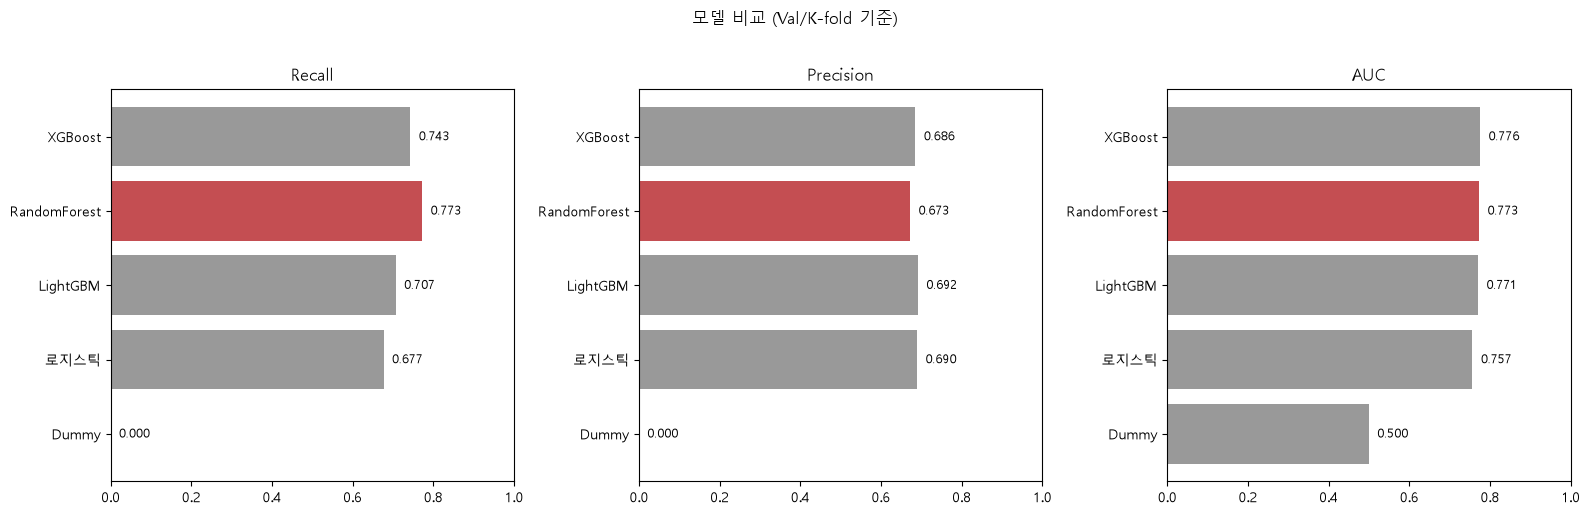

In [57]:
import matplotlib.pyplot as plt
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)
import pandas as pd

# 지금까지 확정된 K-fold 검증 결과 취합
comparison = pd.DataFrame({
    "model": ["Dummy", "로지스틱", "LightGBM", "RandomForest", "XGBoost"],
    "recall": [0.000, 0.677, 0.7071, 0.7727, 0.7434],
    "precision": [0.0, 0.690, 0.6919, 0.6726, 0.6857],
    "auc": [0.5, 0.757, 0.7708, 0.7734, 0.7759],
})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, title in zip(axes, ["recall", "precision", "auc"], ["Recall", "Precision", "AUC"]):
    colors = ["#999999" if m != "RandomForest" else "#C44E52" for m in comparison["model"]]
    ax.barh(comparison["model"], comparison[metric], color=colors)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    for i, v in enumerate(comparison[metric]):
        ax.text(v + 0.02, i, f"{v:.3f}", va="center", fontsize=9)

fig.suptitle("모델 비교 (Val/K-fold 기준)", y=1.02)
plt.tight_layout()
plt.show()

In [58]:
"""모델별 비교표 — (1) 비용 고려 없는 순수 지표 vs (2) 비용 최적화 지표를 나란히 표시.

순수 지표: threshold=0.5 기준 Recall/Precision/AUC (지금까지 팀이 비교해온 방식)
비용 지표: net_benefit이 최대가 되는 threshold에서의 Recall/Precision/순이익
"""

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, recall_score, precision_score, roc_auc_score

AVG_CUSTOMER_VALUE = 3632.34
CAMPAIGN_COST = AVG_CUSTOMER_VALUE / 8    # 약 454
CAMPAIGN_SUCCESS_RATE = 0.15


def cost_curve(proba, y_true):
    thresholds = np.arange(0.05, 0.96, 0.01)
    rows = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        revenue_saved = tp * CAMPAIGN_SUCCESS_RATE * AVG_CUSTOMER_VALUE
        campaign_spend = (tp + fp) * CAMPAIGN_COST
        revenue_lost = fn * AVG_CUSTOMER_VALUE
        net_benefit = revenue_saved - campaign_spend - revenue_lost
        rows.append({
            "threshold": round(t, 2),
            "recall": tp / (tp + fn) if (tp + fn) > 0 else 0,
            "precision": tp / (tp + fp) if (tp + fp) > 0 else 0,
            "net_benefit": round(net_benefit, 1),
        })
    return pd.DataFrame(rows)


candidates = {
    "로지스틱": (best_model, X_val_lr),
    "RandomForest": (final_rf, X_val),
    "XGBoost": (best_xgb_auc, X_val),
    # "LightGBM": (팀원 모델, X_val),
}

rows = []
for name, (model, X_val_use) in candidates.items():
    proba = model.predict_proba(X_val_use)[:, 1]

    # (1) 순수 지표 — threshold=0.5, 비용 고려 없음
    pred_05 = (proba >= 0.5).astype(int)
    pure_recall = recall_score(y_val, pred_05)
    pure_precision = precision_score(y_val, pred_05)
    pure_auc = roc_auc_score(y_val, proba)

    # (2) 비용 최적화 지표
    curve = cost_curve(proba, y_val)
    best_row = curve.loc[curve["net_benefit"].idxmax()]

    rows.append({
        "model": name,
        "[순수] threshold": 0.50,
        "[순수] Recall": round(pure_recall, 3),
        "[순수] Precision": round(pure_precision, 3),
        "[순수] AUC": round(pure_auc, 3),
        "[비용] threshold": best_row["threshold"],
        "[비용] Recall": round(best_row["recall"], 3),
        "[비용] Precision": round(best_row["precision"], 3),
        "[비용] 순이익(£)": best_row["net_benefit"],
    })

summary_df = pd.DataFrame(rows)
pd.set_option("display.width", 140)
print(summary_df.to_string(index=False))

       model  [순수] threshold  [순수] Recall  [순수] Precision  [순수] AUC  [비용] threshold  [비용] Recall  [비용] Precision  [비용] 순이익(£)
        로지스틱             0.5        0.677           0.690     0.757            0.07        0.998           0.513    -148835.1
RandomForest             0.5        0.742           0.680     0.767            0.15        0.984           0.553    -141661.3
     XGBoost             0.5        0.745           0.696     0.771            0.15        0.979           0.557    -145929.3


In [59]:
# risk_segments.py나 customer_scoring.py 쓰던 노트북/파이썬 환경에서
from customer_scoring import load_customer_table
snap = load_customer_table()
print(snap["net_revenue"].mean())

3632.3426053550643


In [60]:
"""각자 자기 모델을 직접 스캔해서 threshold를 찾는다 — 남의 모델 threshold를
빌려쓰지 않기 위함. jhd 팀원이 08~11에서 쓴 것과 동일한 방식:
0.25~0.70 스캔 → Recall>=0.80 후보 중 F1 최대."""

import numpy as np
import pandas as pd
from sklearn.metrics import recall_score, precision_score, f1_score


def scan_threshold(model, X, y_true, recall_floor=0.80):
    proba = model.predict_proba(X)[:, 1]
    thresholds = np.arange(0.25, 0.71, 0.01)
    rows = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        rows.append({
            "threshold": round(t, 2),
            "recall": recall_score(y_true, pred),
            "precision": precision_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
        })
    df = pd.DataFrame(rows)
    ok = df[df["recall"] >= recall_floor]
    if ok.empty:
        best = df.loc[df["f1"].idxmax()]
        note = f"(Recall {recall_floor} 미달 — 전체 구간 F1 최대값으로 대체)"
    else:
        best = ok.loc[ok["f1"].idxmax()]
        note = ""
    return best, note


print("=== 내 RandomForest (final_rf) ===")
best_rf_row, note = scan_threshold(final_rf, X_val, y_val)
print(best_rf_row.to_string(), note)

print("\n=== 내 XGBoost (best_xgb_auc) ===")
best_xgb_row, note = scan_threshold(best_xgb_auc, X_val, y_val)
print(best_xgb_row.to_string(), note)

=== 내 RandomForest (final_rf) ===
threshold    0.350000
recall       0.892272
precision    0.625616
f1           0.735521 

=== 내 XGBoost (best_xgb_auc) ===
threshold    0.340000
recall       0.889930
precision    0.628099
f1           0.736434 


In [ ]:
%%sql


In [61]:
for floor in [0.75, 0.80, 0.85, 0.90]:
    best_row, note = scan_threshold(final_rf, X_val, y_val, recall_floor=floor)
    print(f"목표 Recall≥{floor}: threshold={best_row['threshold']}, "
          f"실제 Recall={best_row['recall']:.3f}, F1={best_row['f1']:.3f} {note}")

목표 Recall≥0.75: threshold=0.35, 실제 Recall=0.892, F1=0.736 
목표 Recall≥0.8: threshold=0.35, 실제 Recall=0.892, F1=0.736 
목표 Recall≥0.85: threshold=0.35, 실제 Recall=0.892, F1=0.736 
목표 Recall≥0.9: threshold=0.32, 실제 Recall=0.913, F1=0.730 


In [63]:
"""과적합 체크 — 같은 threshold(0.35)를 Train과 Val 양쪽에 적용해서 갭을 확인.
갭이 크면(예: Train Recall이 Val보다 훨씬 높으면) 과적합 의심."""

from sklearn.metrics import recall_score, precision_score, f1_score

THRESHOLD = 0.35

for name, X, y in [("Train", X_train, y_train), ("Val", X_val, y_val)]:
    proba = final_rf.predict_proba(X)[:, 1]
    pred = (proba >= THRESHOLD).astype(int)
    print(f"{name}: Recall={recall_score(y, pred):.3f}  "
          f"Precision={precision_score(y, pred):.3f}  "
          f"F1={f1_score(y, pred):.3f}")

train_recall = recall_score(y_train, (final_rf.predict_proba(X_train)[:, 1] >= THRESHOLD).astype(int))
val_recall = recall_score(y_val, (final_rf.predict_proba(X_val)[:, 1] >= THRESHOLD).astype(int))
print(f"\nTrain-Val Recall 갭: {train_recall - val_recall:.3f}")
print("(갭이 0.05 이내면 안정적, 0.1 이상이면 과적합 의심)")

Train: Recall=0.922  Precision=0.631  F1=0.749
Val: Recall=0.892  Precision=0.626  F1=0.736

Train-Val Recall 갭: 0.030
(갭이 0.05 이내면 안정적, 0.1 이상이면 과적합 의심)


In [64]:
"""내 최종 모델(final_rf)을 팀 공통 규칙(models/kmk/model_final.joblib)에 맞춰 저장."""

import joblib
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "models").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("models 폴더를 찾을 수 없음")
    ROOT = ROOT.parent

OUTPUT_PATH = ROOT / "models" / "kmk" / "model_final.joblib"
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(final_rf, OUTPUT_PATH)
print(f"저장 완료: {OUTPUT_PATH}")

# 재로드해서 정상 동작하는지 바로 확인
reloaded = joblib.load(OUTPUT_PATH)
proba_check = reloaded.predict_proba(X_val)[:, 1]
print(f"재로드 확인 — Val 첫 5개 확률: {proba_check[:5].round(3)}")

저장 완료: D:\SKN_AI\Project2\models\kmk\model_final.joblib
재로드 확인 — Val 첫 5개 확률: [0.345 0.605 0.351 0.597 0.8  ]
